# Imports and Store Initialization

In [1]:
%load_ext autoreload
%autoreload 2

from okx import OrderbookStore
import polars as pl
from datetime import date, datetime, timedelta, timezone
from okx.recipes.pillars import prepare_pillars
from evaluation.plotting import plot_error_over_time, plot_error_by_group
from matplotlib import pyplot as plt

store = OrderbookStore(
    data_root="data/okx",
    manifest_path="data/okx/manifest.sqlite"
)

In [ ]:
store.clear_cache()

# Problematic Date Investigation (2025-09-04)
I noticed that our pillars had some occurances where bid is above ask, so I decided to investgate:

In [7]:
def make_dates(start_date, n_days):
    return [start_date + timedelta(days=i) for i in range(n_days)]
dates = make_dates(date(2025, 9, 1), 30) # 30 days in September 2025
print(f"Date range constructed from {dates[0]} to {dates[-1]}")

Date range constructed from 2025-09-01 to 2025-09-30


In [13]:
start = datetime.now()
pillars_lf = prepare_pillars(
    binning='10s',
    store=store,
    inst_family='BTC-USD',
    dates=dates,
    verbose=True
)
end = datetime.now()
print(f"Time taken: {end - start}s")

Constructing pillars for BTC-USD with swap and futures using 10s binning
 - Time taken to fetch swap and futures: 0:00:00.032016
 - Time taken to align snapshots: 0:00:00.000095
 - Time taken to concatenate and filter: 0:00:00.014703
 - Time taken to index and sort pillars: 0:00:00.000209
 - Total time taken to prepare pillars: 0:00:00.047023
Time taken: 0:00:00.047181s


In [16]:
problematic_pillars_df = pillars_lf.filter(pl.col('rel_spread') < 0.0).collect()

first_timeMs = problematic_pillars_df['timeMs'].min()
last_timeMs = problematic_pillars_df['timeMs'].max()
print(f"In a full month of pillar data, there are {problematic_pillars_df.height} rows with a negative spread")
print(f"Earliest occurrence: {datetime.fromtimestamp(first_timeMs / 1000, tz=timezone.utc)}")
print(f"Latest occurrence: {datetime.fromtimestamp(last_timeMs / 1000, tz=timezone.utc)}")

In a full month of pillar data, there are 38 rows with a negative spread
Earliest occurrence: 2025-09-04 03:13:20+00:00
Latest occurrence: 2025-09-04 03:14:00+00:00


let's see if we can get to the bottom of this...

In [4]:
features = ['trim', 'spread', 'times_to_dt']

shared_params = {
    'inst_family': 'BTC-USD',
    'dates': [date(2025, 9, 4)],
    'depth': 2,
    'features': features,
    'binning': None,
    'batch_days': None,
    'verbose': False,
}

lf_swap = store.get(
    inst_type='SWAP',
    **shared_params,
).sort('timeMs')

lf_spot = store.get(
    inst_type='SPOT',
    **shared_params,
).sort('timeMs')

lf_futures = store.get(
    inst_type='FUTURES',
    **shared_params,
).sort(['timeMs', 'symbol'])

lf_options = store.get(
    inst_type='OPTION',
    **shared_params,
).sort(['timeMs', 'symbol'])


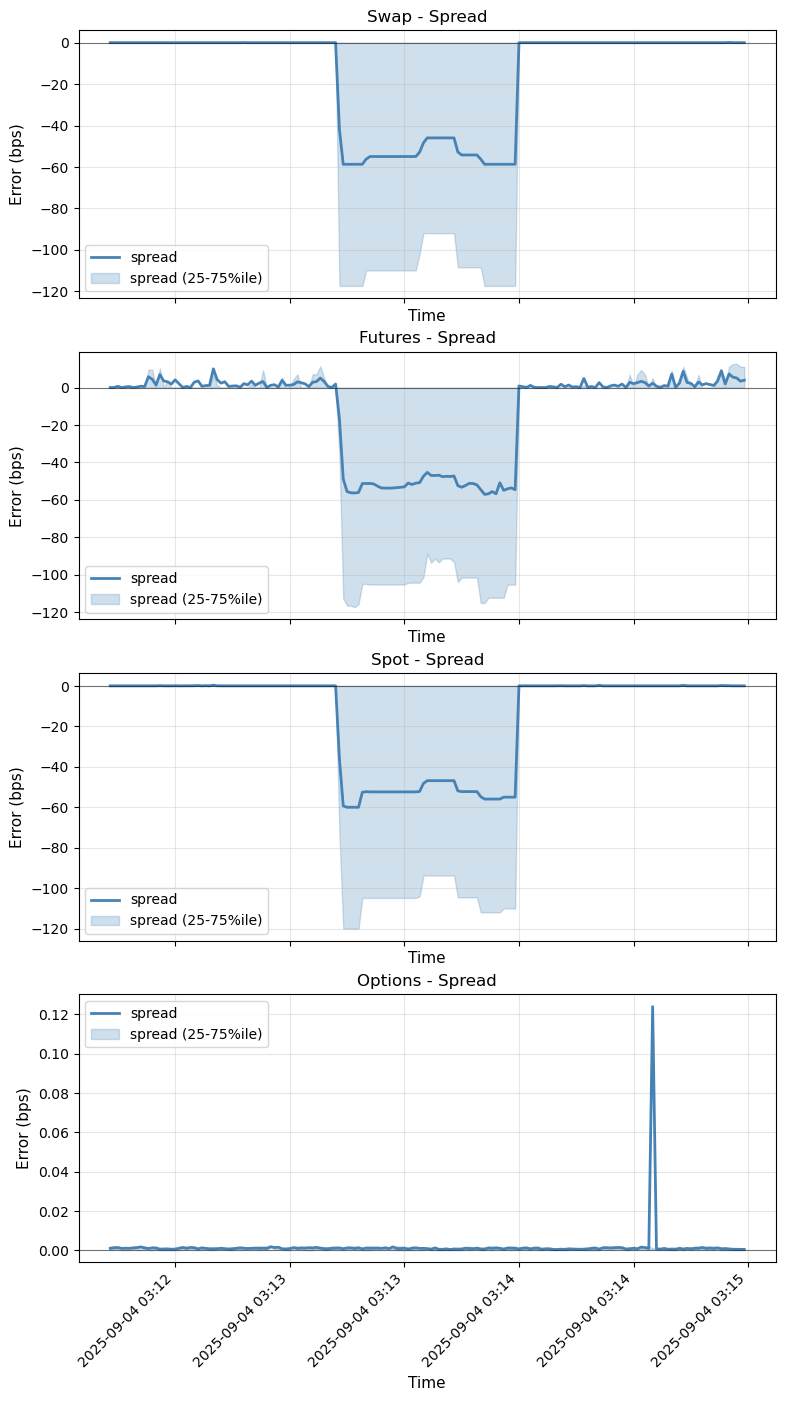

In [5]:
def get_window(lf):
    problems = lf.filter(pl.col('spread') < 0.0)
    problems_df = problems.collect()
    if problems_df.height == 0:
        print("No problems found.")
        return pl.LazyFrame()
    t_min = problems_df['timeMs'].min()
    t_max = problems_df['timeMs'].max()
    # Add 1 minute buffer to each side
    t_min_buf = t_min - timedelta(minutes=1)
    t_max_buf = t_max + timedelta(minutes=1)
    return t_min_buf, t_max_buf

def investigate(lf):
    problems = lf.filter(pl.col('spread') < 0.0)
    problems_df = problems.collect()
    if problems_df.height == 0:
        print("No problems found.")
        return pl.LazyFrame()
    t_min = problems_df['timeMs'].min()
    t_max = problems_df['timeMs'].max()
    # Add 1 minute buffer to each side
    t_min_buf = t_min - timedelta(minutes=1)
    t_max_buf = t_max + timedelta(minutes=1)
    filtered = lf.filter((pl.col('timeMs') >= t_min_buf) & (pl.col('timeMs') <= t_max_buf))
    return filtered

filtered_spot = investigate(lf_spot)
filtered_swap = investigate(lf_swap)
filtered_futures = investigate(lf_futures)
t_min_buf, t_max_buf = get_window(lf_swap)
filtered_options = lf_options.filter((pl.col('timeMs') >= t_min_buf) & (pl.col('timeMs') <= t_max_buf))

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(9, 16))
plot_error_over_time(filtered_swap, 'swap', 'spread', ax=axs[0], resample_freq='1s')
axs[0].set_title('Swap - Spread')
plot_error_over_time(filtered_futures, 'futures', 'spread', ax=axs[1], resample_freq='1s')
axs[1].set_title('Futures - Spread')
plot_error_over_time(filtered_spot, 'spot', 'spread', ax=axs[2], resample_freq='1s')
axs[2].set_title('Spot - Spread')
plot_error_over_time(filtered_options, 'options', 'spread', ax=axs[3], resample_freq='1s')
axs[3].set_title('Options - Spread')
plt.show()

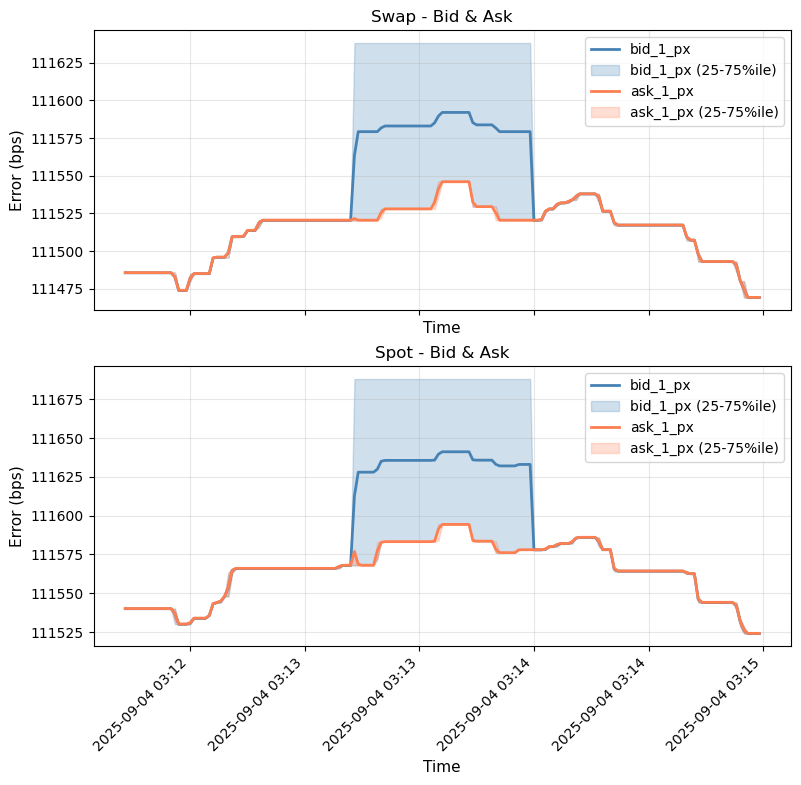

In [10]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(9, 8))
plot_error_over_time(filtered_swap, 'swap', ['bid_1_px', 'ask_1_px'], ax=axs[0], resample_freq='1s', include_zero=False)
axs[0].set_title('Swap - Bid & Ask')
plot_error_over_time(filtered_spot, 'spot', ['bid_1_px', 'ask_1_px'], ax=axs[1], resample_freq='1s', include_zero=False)
axs[1].set_title('Spot - Bid & Ask')
plt.show()

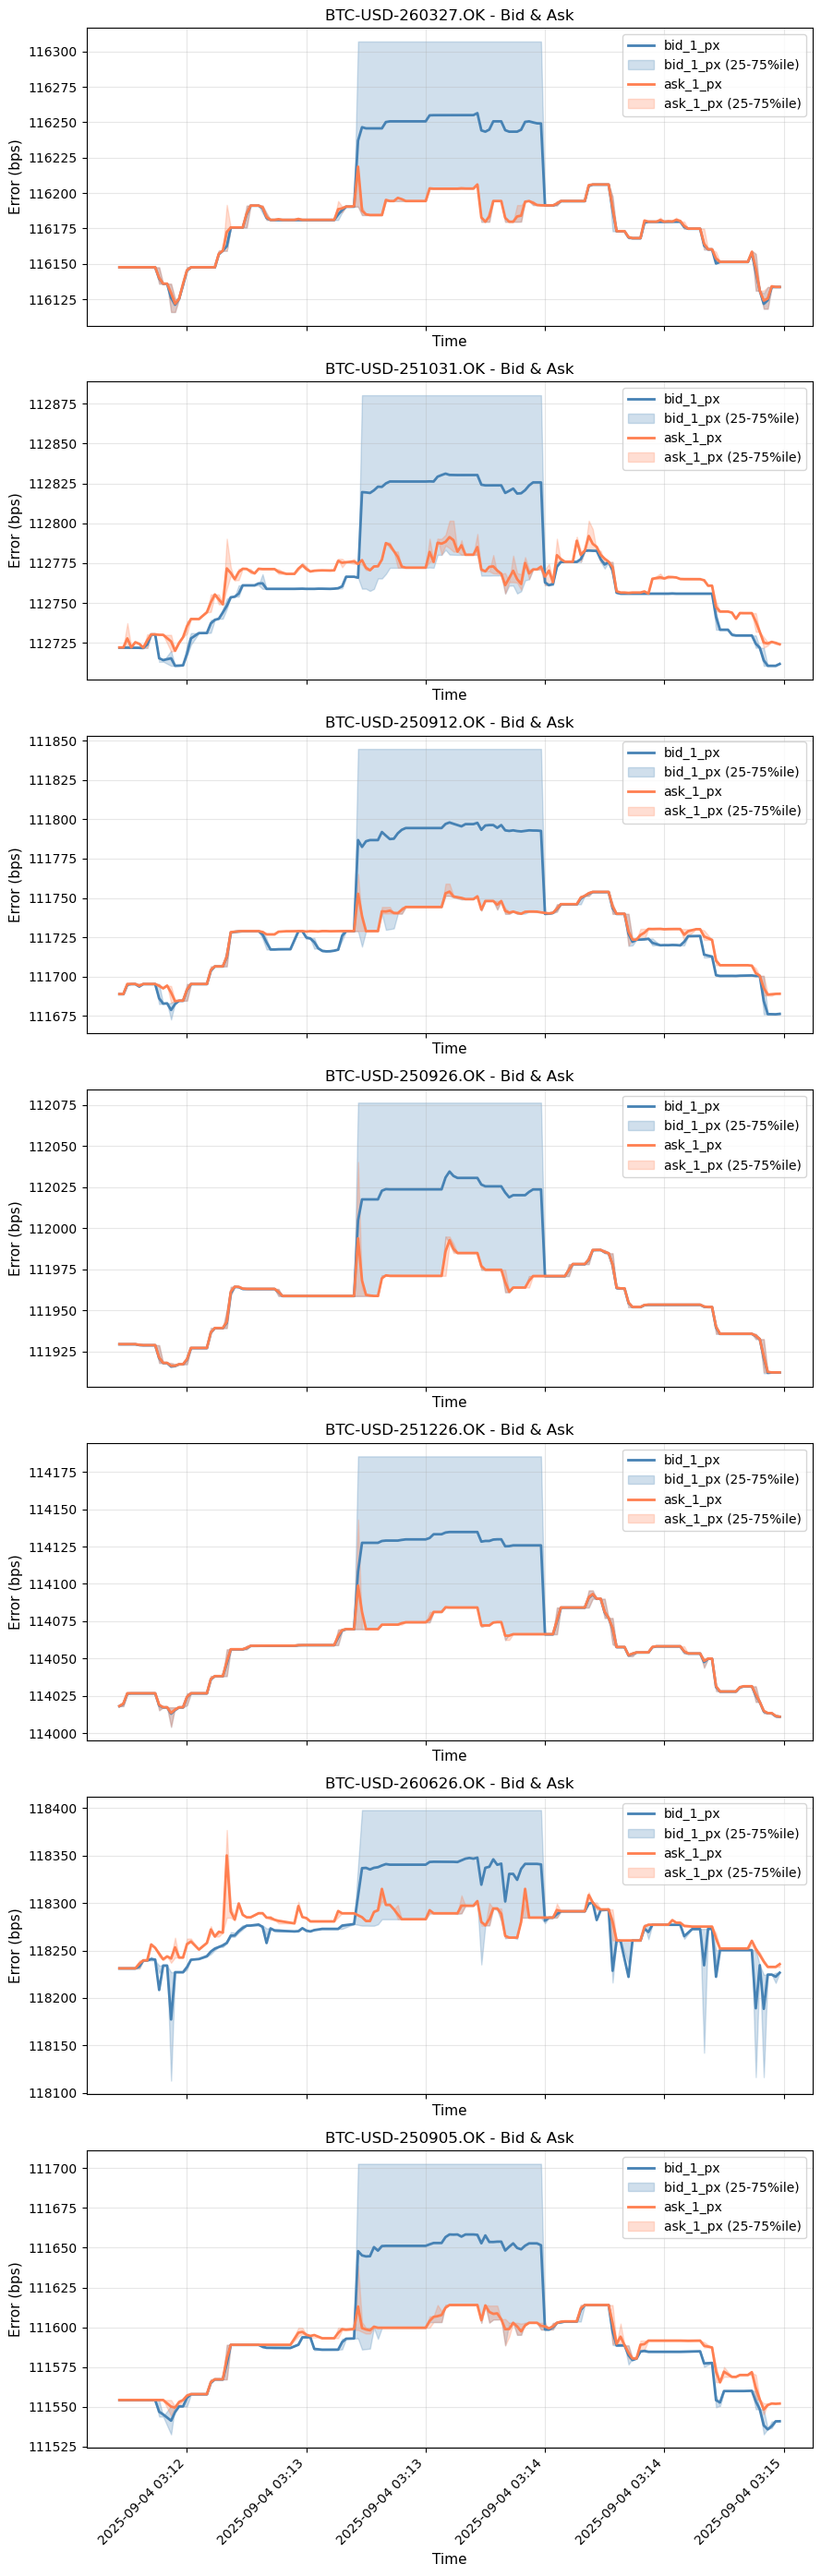

In [9]:
futures_symbols = filtered_futures.select('symbol').unique().collect().get_column('symbol').to_list()
n_symbols = len(futures_symbols)

fig, axs = plt.subplots(n_symbols, 1, sharex=True, figsize=(9, 4 * n_symbols))
for idx, symbol in enumerate(futures_symbols):
    plot_error_over_time(filtered_futures.filter(pl.col('symbol') == symbol), 'futures', ['bid_1_px', 'ask_1_px'], ax=axs[idx], resample_freq='1s', include_zero=False)
    axs[idx].set_title(f'{symbol} - Bid & Ask')
plt.tight_layout()
plt.show()


The options OB data seems to be safe from this anomaly:

In [22]:
problematic_options = lf_options.filter((pl.col('spread').is_not_null()) & (pl.col('spread') < 0.0) & (pl.col('ask_1_px') != 0)).collect()
print(f"Problematic options: {problematic_options.height} rows")
print(problematic_options.select(['timeMs','bid_1_qty', 'bid_1_px', 'spread', 'ask_1_px', 'ask_1_qty']).head(10))


Problematic options: 0 rows
shape: (0, 6)
┌──────────────┬───────────┬──────────┬────────┬──────────┬───────────┐
│ timeMs       ┆ bid_1_qty ┆ bid_1_px ┆ spread ┆ ask_1_px ┆ ask_1_qty │
│ ---          ┆ ---       ┆ ---      ┆ ---    ┆ ---      ┆ ---       │
│ datetime[ms] ┆ f64       ┆ f64      ┆ f64    ┆ f64      ┆ f64       │
╞══════════════╪═══════════╪══════════╪════════╪══════════╪═══════════╡
└──────────────┴───────────┴──────────┴────────┴──────────┴───────────┘


# Store Inspections

General inspections:

In [8]:
def check_bid_null(lf, inst_family, inst_type, date_str):
    bid_null = lf.select(pl.col("bid_1_px").is_null().sum()).collect().item()
    if bid_null != 0:
        print(f"{date_str} {inst_type} bid_null: {bid_null}")

def check_ask_null(lf, inst_family, inst_type, date_str):
    ask_null = lf.select(pl.col("ask_1_px").is_null().sum()).collect().item()
    if ask_null != 0:
        print(f"{date_str} {inst_type} ask_null: {ask_null}")

def check_both_null(lf, inst_family, inst_type, date_str):
    both_null = lf.select((pl.col("bid_1_px").is_null() & pl.col("ask_1_px").is_null()).sum()).collect().item()
    if both_null != 0:
        print(f"{date_str} {inst_type} both_null: {both_null}")

def check_bid_zero(lf, inst_family, inst_type, date_str):
    bid_zero = lf.select((pl.col("bid_1_px") == 0).sum()).collect().item()
    if bid_zero != 0:
        print(f"{date_str} {inst_type} bid_zero: {bid_zero}")

def check_ask_zero(lf, inst_family, inst_type, date_str):
    ask_zero = lf.select((pl.col("ask_1_px") == 0).sum()).collect().item()
    if ask_zero != 0:
        print(f"{date_str} {inst_type} ask_zero: {ask_zero}")

def check_both_zero(lf, inst_family, inst_type, date_str):
    both_zero = lf.select(((pl.col("bid_1_px") == 0) & (pl.col("ask_1_px") == 0)).sum()).collect().item()
    if both_zero != 0:
        print(f"{date_str} {inst_type} both_zero: {both_zero}")

def check_bid_gt_ask(lf, inst_family, inst_type, date_str):
    bid_gt_ask = lf.select((pl.col("bid_1_px") > pl.col("ask_1_px")).sum()).collect().item()
    if bid_gt_ask != 0:
        print(f"{date_str} {inst_type} bid_gt_ask: {bid_gt_ask}")

# _ = store.inspect(check_bid_null, verbose=False) # only triggers for options (expected)
# _ = store.inspect(check_ask_null, verbose=False) # only triggers for options (expected)
# _ = store.inspect(check_both_null, verbose=False) # never triggers
_ = store.inspect(check_bid_zero, verbose=False)
_ = store.inspect(check_ask_zero, verbose=False)
_ = store.inspect(check_both_zero, verbose=False)
_ = store.inspect(check_bid_gt_ask, verbose=False)



2025-09-04 OPTION bid_zero: 49115
2025-09-02 OPTION bid_zero: 72685
2025-09-05 OPTION bid_zero: 97202
2025-09-03 OPTION bid_zero: 74820
2025-09-01 OPTION bid_zero: 42105
2025-09-09 OPTION bid_zero: 64355
2025-09-12 OPTION bid_zero: 123538
2025-09-10 OPTION bid_zero: 50452
2025-09-08 OPTION bid_zero: 65385
2025-09-11 OPTION bid_zero: 49990
2025-09-06 OPTION bid_zero: 195549
2025-09-07 OPTION bid_zero: 129972
2025-01-01 OPTION bid_zero: 43062
2025-08-03 OPTION bid_zero: 196799
2025-08-02 OPTION bid_zero: 278211
2025-08-04 OPTION bid_zero: 140585
2025-08-01 OPTION bid_zero: 334407
2025-08-05 OPTION bid_zero: 131180
2025-08-06 OPTION bid_zero: 144200
2025-08-07 OPTION bid_zero: 103363
2025-08-08 OPTION bid_zero: 290340
2025-08-09 OPTION bid_zero: 141639
2025-08-10 OPTION bid_zero: 106039
2025-08-12 OPTION bid_zero: 186500
2025-08-11 OPTION bid_zero: 195581
2025-08-13 OPTION bid_zero: 142099
2025-08-16 OPTION bid_zero: 288892
2025-08-14 OPTION bid_zero: 222799
2025-08-15 OPTION bid_zero: 25

Sometimes bid or ask is 0 instead of null for options. This happens when there were previously bid/asks listed, but now are none.

We'll investigate the occurance of negative spreads across our entire store:

In [7]:
def problematic_data(lf, inst_family, inst_type, date_str):
    problems = lf.filter((pl.col('bid_1_px') > pl.col('ask_1_px')) & (pl.col('ask_1_px') != 0)).collect()
    problem_count = problems.height
    if problem_count > 0:
        print("-"*100)
        print(f"{date_str} {inst_type} problem_count: {problem_count}")

        first_timeMs = problems['timeMs'].min()
        last_timeMs = problems['timeMs'].max()
        print(f" - First time: {datetime.fromtimestamp(first_timeMs / 1000, tz=timezone.utc)}")
        print(f" - Last time: {datetime.fromtimestamp(last_timeMs / 1000, tz=timezone.utc)}")
        print(f" - Problematic data spans {(last_timeMs - first_timeMs) / 1000} seconds")

        print(problems.select(['timeMs', 'symbol', 'bid_1_qty', 'bid_1_px', 'ask_1_px', 'ask_1_qty']).head(5))
        print("-"*100)
    return problems

results = store.inspect(problematic_data, verbose=True, sort='date')

Inspecting BTC-USD/OPTION/2025-08-25 [101/246]:  41%|████      | 100/246 [00:08<00:11, 12.20it/s] 

----------------------------------------------------------------------------------------------------
2025-08-25 SWAP problem_count: 337
 - First time: 2025-08-25 02:23:29.041000+00:00
 - Last time: 2025-08-25 02:23:33.611000+00:00
 - Problematic data spans 4.57 seconds
shape: (5, 6)
┌───────────────┬─────────────────┬───────────┬──────────┬──────────┬───────────┐
│ timeMs        ┆ symbol          ┆ bid_1_qty ┆ bid_1_px ┆ ask_1_px ┆ ask_1_qty │
│ ---           ┆ ---             ┆ ---       ┆ ---      ┆ ---      ┆ ---       │
│ i64           ┆ str             ┆ f64       ┆ f64      ┆ f64      ┆ f64       │
╞═══════════════╪═════════════════╪═══════════╪══════════╪══════════╪═══════════╡
│ 1756088609041 ┆ BTC-USD-SWAP.OK ┆ 348.0     ┆ 113562.5 ┆ 113550.1 ┆ 4739.0    │
│ 1756088609051 ┆ BTC-USD-SWAP.OK ┆ 262.0     ┆ 113566.1 ┆ 113550.1 ┆ 4739.0    │
│ 1756088609070 ┆ BTC-USD-SWAP.OK ┆ 399.0     ┆ 113574.3 ┆ 113550.1 ┆ 4739.0    │
│ 1756088609080 ┆ BTC-USD-SWAP.OK ┆ 399.0     ┆ 113574.3 ┆ 1

Inspecting BTC-USD/OPTION/2025-08-26 [105/246]:  42%|████▏     | 104/246 [00:09<00:14,  9.93it/s] 

----------------------------------------------------------------------------------------------------
2025-08-25 SPOT problem_count: 319
 - First time: 2025-08-25 02:23:29.040000+00:00
 - Last time: 2025-08-25 02:23:34.310000+00:00
 - Problematic data spans 5.27 seconds
shape: (5, 6)
┌───────────────┬────────────┬───────────┬──────────┬──────────┬───────────┐
│ timeMs        ┆ symbol     ┆ bid_1_qty ┆ bid_1_px ┆ ask_1_px ┆ ask_1_qty │
│ ---           ┆ ---        ┆ ---       ┆ ---      ┆ ---      ┆ ---       │
│ i64           ┆ str        ┆ f64       ┆ f64      ┆ f64      ┆ f64       │
╞═══════════════╪════════════╪═══════════╪══════════╪══════════╪═══════════╡
│ 1756088609040 ┆ BTC-USD.OK ┆ 0.0037    ┆ 113613.1 ┆ 113575.9 ┆ 1.432232  │
│ 1756088609050 ┆ BTC-USD.OK ┆ 0.0037    ┆ 113613.1 ┆ 113575.9 ┆ 1.432232  │
│ 1756088609060 ┆ BTC-USD.OK ┆ 0.040181  ┆ 113613.2 ┆ 113575.9 ┆ 1.432232  │
│ 1756088609110 ┆ BTC-USD.OK ┆ 0.040181  ┆ 113613.2 ┆ 113575.9 ┆ 1.432232  │
│ 1756088609141 ┆ BTC-U

Inspecting BTC-USD/OPTION/2025-09-04 [141/246]:  57%|█████▋    | 140/246 [00:12<00:08, 12.30it/s] 

...

Inspecting BTC-USD/OPTION/2025-09-05 [145/246]:  59%|█████▊    | 144/246 [00:13<00:08, 12.34it/s] 

----------------------------------------------------------------------------------------------------
2025-09-04 SPOT problem_count: 1654
 - First time: 2025-09-04 03:13:13.392000+00:00
 - Last time: 2025-09-04 03:13:59.996000+00:00
 - Problematic data spans 46.604 seconds
shape: (5, 6)
┌───────────────┬────────────┬───────────┬──────────┬──────────┬───────────┐
│ timeMs        ┆ symbol     ┆ bid_1_qty ┆ bid_1_px ┆ ask_1_px ┆ ask_1_qty │
│ ---           ┆ ---        ┆ ---       ┆ ---      ┆ ---      ┆ ---       │
│ i64           ┆ str        ┆ f64       ┆ f64      ┆ f64      ┆ f64       │
╞═══════════════╪════════════╪═══════════╪══════════╪══════════╪═══════════╡
│ 1756955593392 ┆ BTC-USD.OK ┆ 0.102854  ┆ 111688.0 ┆ 111614.9 ┆ 0.002688  │
│ 1756955593442 ┆ BTC-USD.OK ┆ 0.102854  ┆ 111688.0 ┆ 111614.9 ┆ 0.002688  │
│ 1756955593452 ┆ BTC-USD.OK ┆ 0.102854  ┆ 111688.0 ┆ 111614.9 ┆ 0.002688  │
│ 1756955593492 ┆ BTC-USD.OK ┆ 0.102854  ┆ 111688.0 ┆ 111614.9 ┆ 0.002688  │
│ 1756955593552 ┆ BT

Inspecting BTC-USD/FUTURES/2025-09-13 [176/246]:  71%|███████   | 174/246 [00:15<00:04, 14.92it/s]

----------------------------------------------------------------------------------------------------
2025-09-12 FUTURES problem_count: 8
 - First time: 2025-09-12 07:26:01.233000+00:00
 - Last time: 2025-09-12 07:26:01.733000+00:00
 - Problematic data spans 0.5 seconds
shape: (5, 6)
┌───────────────┬───────────────────┬───────────┬──────────┬──────────┬───────────┐
│ timeMs        ┆ symbol            ┆ bid_1_qty ┆ bid_1_px ┆ ask_1_px ┆ ask_1_qty │
│ ---           ┆ ---               ┆ ---       ┆ ---      ┆ ---      ┆ ---       │
│ i64           ┆ str               ┆ f64       ┆ f64      ┆ f64      ┆ f64       │
╞═══════════════╪═══════════════════╪═══════════╪══════════╪══════════╪═══════════╡
│ 1757661961233 ┆ BTC-USD-260626.OK ┆ 5.0       ┆ 122209.8 ┆ 122206.0 ┆ 75.0      │
│ 1757661961293 ┆ BTC-USD-260327.OK ┆ 2.0       ┆ 120099.1 ┆ 120096.8 ┆ 7.0       │
│ 1757661961343 ┆ BTC-USD-260327.OK ┆ 2.0       ┆ 120099.1 ┆ 120096.8 ┆ 7.0       │
│ 1757661961443 ┆ BTC-USD-260327.OK ┆ 2.0   

Inspecting BTC-USD/SPOT/2025-09-30 [246/246]: 100%|██████████| 246/246 [00:19<00:00, 12.39it/s]   


At the time of running this code, we have problematic OB entries (negative spread) in the following places:
 - 2025-08-25 for 4-7s in SPOT, SWAP, and FUTURES.
 - 2025-08-26 for 22.2s in FUTURES.
 - 2025-09-04 for 46.6s in SPOT, SWAP, and FUTURES.
 - 2025-09-12 for 0.5s in FUTURES

We'll verify our hypothesis that null bid/ask indicates no previous bid/asks, while zero bid/ask indicates a previous bid/ask, but no current bid/ask.

In [9]:
def verify_hypothesis(lf, inst_family, inst_type, date_str):
    if inst_type != 'OPTION':
        return # This only applies to options
    
    def check_side(side_name, px_col):
        """
        Helper to verify:
        - If px is null → no previous non-null px should exist for that symbol
        - If px is zero → previous non-null px should exist for that symbol
        """
        violations = []
        
        # Check null case
        df_null = lf.filter(pl.col(px_col).is_null()).collect()
        if not df_null.is_empty():
            for symbol in df_null.get_column("symbol").unique():
                first_timeMs = (
                    df_null
                    .filter(pl.col("symbol") == symbol)
                    .sort("timeMs")
                    .get_column("timeMs")[0]
                )
                prev = lf.filter(
                    (pl.col("symbol") == symbol) & (pl.col("timeMs") < first_timeMs)
                ).collect()
                has_prev_nonnull = (prev.get_column(px_col).is_null() == False).any() if prev.height > 0 else False
                
                if has_prev_nonnull:
                    violations.append(f"  ❌ {side_name} is null (symbol={symbol}, timeMs={first_timeMs}) but previous non-null exists")
        
        # Check zero case
        df_zero = lf.filter(pl.col(px_col) == 0).collect()
        if not df_zero.is_empty():
            for symbol in df_zero.get_column("symbol").unique():
                first_timeMs = (
                    df_zero
                    .filter(pl.col("symbol") == symbol)
                    .sort("timeMs")
                    .get_column("timeMs")[0]
                )
                prev = lf.filter(
                    (pl.col("symbol") == symbol) & (pl.col("timeMs") < first_timeMs)
                ).collect()
                has_prev_nonnull = (prev.get_column(px_col).is_null() == False).any() if prev.height > 0 else False
                
                if not has_prev_nonnull:
                    violations.append(f"  ❌ {side_name} is zero (symbol={symbol}, timeMs={first_timeMs}) but no previous non-null exists")
        
        return violations
    
    print(f"\nVerifying null/zero hypothesis for {inst_family} {inst_type} on {date_str}...")
    
    bid_violations = check_side("bid", "bid_1_px")
    ask_violations = check_side("ask", "ask_1_px")
    
    all_violations = bid_violations + ask_violations
    
    if all_violations:
        print("❌ Found violations:")
        for v in all_violations:
            print(v)
    else:
        print("✓ No violations found - hypothesis holds!")

In [10]:
_ = store.inspect(verify_hypothesis, verbose=True, sort='inst_type')

Inspecting BTC-USD/OPTION/2025-09-04 [65/246]:   0%|          | 0/246 [00:00<?, ?it/s] 


Verifying null/zero hypothesis for BTC-USD OPTION on 2025-09-04...


Inspecting BTC-USD/OPTION/2025-09-04 [65/246]:  26%|██▌       | 64/246 [00:27<01:18,  2.33it/s]


KeyboardInterrupt: 

This takes too long, but my hypothesis was verified on the one day of data shown below so I'll just assume it to be true for now. Can't be bothered to make the inspect function more efficient.

In [9]:
# For each symbol that has any (bid != 0 and ask is null), check if ask has ever been non-null for that symbol prior to the first such time
df_bid_nonzero_ask_null = options_lf.filter(
    (pl.col("bid_1_px") != 0) & (pl.col("ask_1_px").is_null())
).collect()

if not df_bid_nonzero_ask_null.is_empty():
    for symbol in df_bid_nonzero_ask_null.get_column("symbol").unique():
        # get the first time this occurs for this symbol
        first_timeMs = (
            df_bid_nonzero_ask_null
            .filter(pl.col("symbol") == symbol)
            .sort("timeMs")
            .get_column("timeMs")[0]
        )
        prev = options_lf.filter(
            (pl.col("symbol") == symbol) & (pl.col("timeMs") < first_timeMs)
        ).collect()
        has_prev_nonnull_ask = (prev.get_column("ask_1_px").is_null() == False).any() if prev.height > 0 else False
        print(f"For bid!=0 and ask=null (symbol={symbol}, first_timeMs={first_timeMs}):")
        print(f"Previous ask_1_px non-null exists? {has_prev_nonnull_ask}")

# For each symbol that has any (bid != 0 and ask == 0), check if ask has ever been non-null for that symbol prior to the first such time
df_bid_nonzero_ask_zero = options_lf.filter(
    (pl.col("bid_1_px") != 0) & (pl.col("ask_1_px") == 0)
).collect()

if not df_bid_nonzero_ask_zero.is_empty():
    for symbol in df_bid_nonzero_ask_zero.get_column("symbol").unique():
        first_timeMs = (
            df_bid_nonzero_ask_zero
            .filter(pl.col("symbol") == symbol)
            .sort("timeMs")
            .get_column("timeMs")[0]
        )
        prev = options_lf.filter(
            (pl.col("symbol") == symbol) & (pl.col("timeMs") < first_timeMs)
        ).collect()
        had_nonnull_ask = (prev.get_column("ask_1_px").is_null() == False).any() if prev.height > 0 else False
        print(f"For bid!=0 and ask==0 (symbol={symbol}, first_timeMs={first_timeMs}):")
        print(f"Previous ask_1_px non-null exists? {had_nonnull_ask}")

For bid!=0 and ask=null (symbol=BTC-USD-260925-200000-C.OK, first_timeMs=1757666194695):
Previous ask_1_px non-null exists? False
For bid!=0 and ask=null (symbol=BTC-USD-260925-80000-P.OK, first_timeMs=1757666194704):
Previous ask_1_px non-null exists? False
For bid!=0 and ask=null (symbol=BTC-USD-260327-30000-C.OK, first_timeMs=1757660821288):
Previous ask_1_px non-null exists? False
For bid!=0 and ask=null (symbol=BTC-USD-260327-40000-C.OK, first_timeMs=1757660821358):
Previous ask_1_px non-null exists? False
For bid!=0 and ask=null (symbol=BTC-USD-260925-170000-C.OK, first_timeMs=1757666194704):
Previous ask_1_px non-null exists? False
For bid!=0 and ask=null (symbol=BTC-USD-260925-150000-P.OK, first_timeMs=1757666194705):
Previous ask_1_px non-null exists? False
For bid!=0 and ask==0 (symbol=BTC-USD-250926-90000-C.OK, first_timeMs=1757656402688):
Previous ask_1_px non-null exists? True
For bid!=0 and ask==0 (symbol=BTC-USD-250914-110000-C.OK, first_timeMs=1757656402688):
Previous a

# Find minimum tick size

In [13]:
def find_min_tick_size(lf, inst_family, inst_type, date_str):
    # Efficiently get all bid/ask price values (as a single list)
    df = lf.select(["bid_1_px", "ask_1_px"]).collect()
    prices = pl.concat([df["bid_1_px"], df["ask_1_px"]], rechunk=True)
    unique_prices = prices.unique().sort()
    # Compute min diff between sorted unique prices (excluding zeros and nans)
    clean_prices = unique_prices.filter((unique_prices != 0) & unique_prices.is_not_null()).to_numpy()
    if len(clean_prices) < 2:
        print("No valid ticks found")
        return
    diffs = clean_prices[1:] - clean_prices[:-1]
    min_diff = diffs[diffs > 0].min() if (diffs > 0).any() else None
    if min_diff is not None:
        # Round to 1 significant figure, print as a "normal" number
        if min_diff == 0:
            rounded_tick = 0
        else:
            from math import log10, floor
            sig_digits = 1
            order = floor(log10(abs(min_diff)))
            rounded_tick = round(min_diff, -order + (sig_digits - 1))
            # Convert to float to avoid scientific notation (unless very small/large)
            rounded_tick_str = f"{rounded_tick:.10f}".rstrip("0").rstrip(".")
        print(f"Minimum tick size for {inst_family}/{inst_type}/{date_str}: {rounded_tick_str}")
    else:
        print(f"Minimum tick size for {inst_family}/{inst_type}/{date_str}: {min_diff}")

In [14]:
_ = store.inspect(find_min_tick_size, verbose=True, sort='inst_type')

Inspecting BTC-USD/FUTURES/2025-09-03 [1/246]:   0%|          | 0/246 [00:00<?, ?it/s]

Inspecting BTC-USD/FUTURES/2025-09-01 [3/246]:   1%|          | 2/246 [00:00<00:25,  9.47it/s]

Minimum tick size for BTC-USD/FUTURES/2025-09-03: 0.1
Minimum tick size for BTC-USD/FUTURES/2025-09-04: 0.1


Inspecting BTC-USD/FUTURES/2025-09-06 [6/246]:   2%|▏         | 4/246 [00:00<00:29,  8.25it/s]

Minimum tick size for BTC-USD/FUTURES/2025-09-01: 0.1
Minimum tick size for BTC-USD/FUTURES/2025-09-02: 0.1
Minimum tick size for BTC-USD/FUTURES/2025-09-07: 0.1


...

Minimum tick size for BTC-USD/SWAP/2025-08-13: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-14: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-19: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-18: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-20: 0.1


Inspecting BTC-USD/SWAP/2025-08-25 [241/246]:  97%|█████████▋| 239/246 [00:26<00:00, 26.13it/s]

Minimum tick size for BTC-USD/SWAP/2025-08-21: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-22: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-23: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-24: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-27: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-26: 0.1


Inspecting BTC-USD/SWAP/2025-08-03 [246/246]: 100%|██████████| 246/246 [00:26<00:00,  9.26it/s]

Minimum tick size for BTC-USD/SWAP/2025-08-25: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-28: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-30: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-31: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-29: 0.1
Minimum tick size for BTC-USD/SWAP/2025-08-03: 0.1


Tick size for SPOT, SWAP, and FUTURES is 0.1 USD.

Tick size for OPTIONS is 0.0001 BTC.